In [1]:

import pandas as pd
import numpy as np
#  Load essential data analysis libraries:
# - pandas (pd): for loading, cleaning, and managing tabular survey data
# - numpy (np): for mathematical operations and defining missing values (NaN)


In [2]:
#Load raw dataset 

df_raw = pd.read_csv('../data/raw/WVS_Survey_Trimmed.csv', low_memory=False)


In [3]:
# Define the list of essential variables needed for the analysis
need = ['B_COUNTRY_ALPHA', 'W_WEIGHT', 'Q51', 'Q53', 'Q54', 'Q55']

# Check for missing columns in the raw DataFrame (returns [] if all columns exist)
print([c for c in need if c not in df_raw.columns])   # should print []

[]


In [4]:

# selecting core required variables 
need = ['B_COUNTRY_ALPHA', 'W_WEIGHT', 'Q51', 'Q53', 'Q54', 'Q55']
df = df_raw[need].copy()

# make sure the survey items and weight are numeric
for c in ['W_WEIGHT', 'Q51', 'Q53', 'Q54', 'Q55']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# WVS missing codes (all negative) -> NaN
items = {'Q51': 'food', 'Q53': 'medicine', 'Q54': 'cash_income', 'Q55': 'shelter'}
for q in items:
    df[q] = df[q].where(df[q] > 0)

# recoding country codes into country names 
country_map = {
    'MMR': 'Myanmar', 'IDN': 'Indonesia', 'MYS': 'Malaysia',
    'PHL': 'Philippines', 'SGP': 'Singapore', 'VNM': 'Vietnam', 'THA': 'Thailand'
}
sea = df[df['B_COUNTRY_ALPHA'].isin(country_map)].copy()

# 1=Often, 2=Sometimes, 3=Rarely, 4=Never -> 4,3,2,1
for q in items:
    sea[q] = 5 - sea[q]

In [5]:
# Generate a summary frequency table for all hardship items (Q51, Q53, Q54, Q55)
# Checks category distribution (1-4) and counts missing values (NaN) per column
print(sea[list(items)].apply(lambda s: s.value_counts(dropna=False).sort_index()))

      Q51   Q53   Q54   Q55
1.0  7690  6808  6182  9611
2.0  1703  2380  2211  1035
3.0  1640  1745  2415   633
4.0   585   677   806   332
NaN     7    15    11    14


In [6]:
# Helper function to compute weighted mean for a column while ignoring missing values
def wmean(g, col):
    # Remove rows where either the variable or survey weight is NaN
    g = g.dropna(subset=[col, 'W_WEIGHT'])
    # Calculate weighted average using NumPy
    return np.average(g[col], weights=g['W_WEIGHT'])

# Calculate weighted average for each hardship item across each SEA country
res = pd.DataFrame({
    name: {c: wmean(g, q) for c, g in sea.groupby('B_COUNTRY_ALPHA')}
    for q, name in items.items()
})

# Rename row indices from 3-letter alpha codes (e.g., 'SGP') to full country names ('Singapore')
res.index = res.index.map(country_map)

# Display final summary table with values rounded to 3 decimal places
res.round(3)

# The higher the score, the higher the economic hardship in the country

,food,medicine,cash_income,shelter
Indonesia,1.886,2.115,1.968,1.308
Myanmar,1.346,1.282,1.882,1.231
Malaysia,1.460,1.617,1.788,1.313
Philippines,1.893,1.990,2.129,1.388
Singapore,1.128,1.155,1.301,1.064
Thailand,1.811,1.780,2.020,1.613
Vietnam,1.214,1.369,1.612,1.068


In [7]:
#calculating the mean deprivation score 
res['deprivation_mean'] = res.mean(axis=1)
res.round(3)

,food,medicine,cash_income,shelter,deprivation_mean
Indonesia,1.886,2.115,1.968,1.308,1.819
Myanmar,1.346,1.282,1.882,1.231,1.435
Malaysia,1.460,1.617,1.788,1.313,1.545
Philippines,1.893,1.990,2.129,1.388,1.850
Singapore,1.128,1.155,1.301,1.064,1.162
Thailand,1.811,1.780,2.020,1.613,1.806
Vietnam,1.214,1.369,1.612,1.068,1.316


In [8]:
#saving the mean deprivation score of each country as a dataframe
deprivation_df = (
    res[['deprivation_mean']]
    .round(3)
    .reset_index()
    .rename(columns={'index': 'country'})
    .sort_values('deprivation_mean', ascending=False)
    .reset_index(drop=True)
)
deprivation_df

,country,deprivation_mean
0,Philippines,1.850
1,Indonesia,1.819
2,Thailand,1.806
3,Malaysia,1.545
4,Myanmar,1.435
5,Vietnam,1.316
6,Singapore,1.162


# Ethical Values and Norms Q177 - 181
Creating column headers for output table based on question numbers.

In [9]:
# Q177-181: justifiability of economic norm violations (1 = Never justifiable, 10 = Always justifiable)
questions = {
    'Q177': 'benefits',         # Claiming government benefits you're not entitled to
    'Q178': 'fare_avoidance',   # Avoiding a fare on public transport
    'Q179': 'stealing',         # Stealing property
    'Q180': 'tax_cheating',     # Cheating on taxes if you have a chance
    'Q181': 'bribery'           # Someone accepting a bribe in the course of their duties
}

Map the abbreviations for the countries to their actual names.

In [10]:
sea_countries = {
    'IDN': 'Indonesia',
    'MMR': 'Myanmar',
    'MYS': 'Malaysia',
    'PHL': 'Philippines',
    'SGP': 'Singapore',
    'THA': 'Thailand',
    'VNM': 'Vietnam'
}


Filtering our dataset file to the 7 Southeast Asian countries above.

In [11]:
df = df_raw[df_raw['B_COUNTRY_ALPHA'].isin(sea_countries.keys())].copy()

Filtering out missing or 'don't know' responses, keeping only valid answers. Then we calculate the weighted average of the responses, using each respondent's survey weight as provided in the dataset (W_WEIGHT) to correct for sampling design.

In [12]:
def weighted_mean(group, col):
    valid = group[group[col] > 0]   # drop negative missing/don't-know codes
    return np.average(valid[col], weights=valid['W_WEIGHT'])

Calculating the weighted mean for each question, separately for each country.

In [13]:
results = {}
for q_col, label in questions.items():
    results[label] = df.groupby('B_COUNTRY_ALPHA').apply(lambda g: weighted_mean(g, q_col))

Lastly, we organise the results into a table.

In [14]:
result_df = pd.DataFrame(results)
result_df.index = result_df.index.map(sea_countries)
result_df = result_df.round(3)
print(result_df)

                 benefits  fare_avoidance  stealing  tax_cheating  bribery
B_COUNTRY_ALPHA                                                           
Indonesia           3.343           2.802     1.583         2.582    1.939
Myanmar             3.655           3.161     1.489         1.622    1.722
Malaysia            4.395           3.979     3.100         3.409    3.085
Philippines         5.211           4.805     3.646         4.041    4.104
Singapore           2.534           1.823     1.351         1.538    1.412
Thailand            2.223           2.231     1.832         1.744    1.774
Vietnam             4.524           3.424     2.495         2.832    2.898


Rescale to a 0 to 1 scale so that we can compare fairly, since these are measured on a 1 to 10 scale and the earlier questions are measured on a 1 to 4 scale.

In [15]:
result_df_rescaled = ((result_df - 1) / 9).round(3)
print(result_df_rescaled)

                 benefits  fare_avoidance  stealing  tax_cheating  bribery
B_COUNTRY_ALPHA                                                           
Indonesia           0.260           0.200     0.065         0.176    0.104
Myanmar             0.295           0.240     0.054         0.069    0.080
Malaysia            0.377           0.331     0.233         0.268    0.232
Philippines         0.468           0.423     0.294         0.338    0.345
Singapore           0.170           0.091     0.039         0.060    0.046
Thailand            0.136           0.137     0.092         0.083    0.086
Vietnam             0.392           0.269     0.166         0.204    0.211


Next, we calculate the mean Economic Violation (EV) score by averaging the numbers across the 5 questions for each country.

In [16]:
#calculating the mean Economic Violation (EV) score 
result_df_rescaled['EV_mean'] = result_df_rescaled.mean(axis=1)
result_df_rescaled.round(3)

,benefits,fare_avoidance,stealing,tax_cheating,bribery,EV_mean
B_COUNTRY_ALPHA,,,,,,
Indonesia,0.260,0.200,0.065,0.176,0.104,0.161
Myanmar,0.295,0.240,0.054,0.069,0.080,0.148
Malaysia,0.377,0.331,0.233,0.268,0.232,0.288
Philippines,0.468,0.423,0.294,0.338,0.345,0.374
Singapore,0.170,0.091,0.039,0.060,0.046,0.081
Thailand,0.136,0.137,0.092,0.083,0.086,0.107
Vietnam,0.392,0.269,0.166,0.204,0.211,0.248


Creating a separate table for the EV score.

In [17]:
#putting the aggregate Economic Violation (EV) score into a data frame
EV_df = (
    result_df_rescaled['EV_mean']
    .round(3)
    .reset_index()
    .rename(columns={'index': 'country'})
    .sort_values('EV_mean', ascending=False)
    .reset_index(drop=True)
)
EV_df



,B_COUNTRY_ALPHA,EV_mean
0,Philippines,0.374
1,Malaysia,0.288
2,Vietnam,0.248
3,Indonesia,0.161
4,Myanmar,0.148
5,Thailand,0.107
6,Singapore,0.081


In [18]:
#renaming of column to "country"

EV1_df = EV_df.rename(columns={'B_COUNTRY_ALPHA': 'country'})
EV1_df

,country,EV_mean
0,Philippines,0.374
1,Malaysia,0.288
2,Vietnam,0.248
3,Indonesia,0.161
4,Myanmar,0.148
5,Thailand,0.107
6,Singapore,0.081


# Personal norms 
Checking the dimensions of the dataset. 

In [19]:
pd.set_option("display.max_columns", None)

print(df_raw.shape)
print(df_raw.columns.tolist())
print(df_raw.head(10))

(11625, 260)
['version', 'doi', 'A_WAVE', 'A_YEAR', 'A_STUDY', 'B_COUNTRY', 'B_COUNTRY_ALPHA', 'C_COW_NUM', 'C_COW_ALPHA', 'D_INTERVIEW', 'S007', 'J_INTDATE', 'FW_START', 'FW_END', 'K_TIME_START', 'K_TIME_END', 'K_DURATION', 'Q_MODE', 'N_REGION_ISO', 'N_REGION_WVS', 'N_REGION_NUTS2', 'N_REG_NUTS1', 'N_TOWN', 'G_TOWNSIZE', 'G_TOWNSIZE2', 'H_SETTLEMENT', 'H_URBRURAL', 'I_PSU', 'O1_LONGITUDE', 'O2_LATITUDE', 'L_INTERVIEWER_NUMBER', 'S_INTLANGUAGE', 'LNGE_ISO', 'E_RESPINT', 'F_INTPRIVACY', 'E1_LITERACY', 'W_WEIGHT', 'S018', 'PWGHT', 'S025', 'Q51', 'Q53', 'Q54', 'Q55', 'Q177', 'Q178', 'Q179', 'Q180', 'Q181', 'Q182', 'Q183', 'Q184', 'Q185', 'Q186', 'Q187', 'Q188', 'Q189', 'Q190', 'Q191', 'Q192', 'Q193', 'Q194', 'Q195', 'Q287', 'Q288', 'Q288R', 'Y001', 'Y002', 'Y003', 'SACSECVAL', 'RESEMAVAL', 'I_AUTHORITY', 'I_NATIONALISM', 'I_DEVOUT', 'DEFIANCE', 'I_RELIGIMP', 'I_RELIGBEL', 'I_RELIGPRAC', 'DISBELIEF', 'I_NORM1', 'I_NORM2', 'I_NORM3', 'RELATIVISM', 'I_TRUSTARMY', 'I_TRUSTPOLICE', 'I_TRUSTCOU

Focus on only ASEAN countries by creating a dataframe with only those specific countries

In [20]:
# only focus on the ASEAN countries

country_col = "B_COUNTRY_ALPHA"

country_map = {
    'MMR': 'Myanmar', 'IDN': 'Indonesia', 'MYS': 'Malaysia',
    'PHL': 'Philippines', 'SGP': 'Singapore', 'VNM': 'Vietnam', 'THA': 'Thailand'
}

df_sea = df_raw[df_raw[country_col].isin(country_map.keys())].copy()



Focus on only the columns that are related to Personal norms and calling is 'q_cols'

In [21]:
# Use the Q182-Q195 columns only
q_cols = [f"Q{i}" for i in range(182, 196)]

Data cleaning: removal of missing code and changing variable type to numeric 

In [22]:
#change the variable into numeric and remove missing code
df_sea[q_cols] = df_sea[q_cols].apply(pd.to_numeric, errors="coerce")
df_sea[q_cols] = df_sea[q_cols].where(df_sea[q_cols] > 0)

Printing the mean column for every question for the respective countries 

In [23]:
question_means = df_sea.groupby(country_col)[q_cols].mean()
print(question_means.round(2))

                 Q182  Q183  Q184  Q185  Q186  Q187  Q188  Q189  Q190  Q191  \
B_COUNTRY_ALPHA                                                               
IDN              1.61  1.57  1.58  2.69  1.64  1.48  2.19  1.67  2.44  1.86   
MMR              1.72  1.85  1.41  2.45  1.63  1.36  1.95  1.53  5.04  1.44   
MYS              3.59  3.39  3.52  4.64  3.82  3.15  3.95  3.13  4.47  3.28   
PHL              4.57  3.77  3.02  4.20  4.31  3.13  3.62  3.44  3.96  3.73   
SGP              3.45  2.78  3.29  4.21  4.04  2.46  4.19  1.32  3.36  1.58   
THA              4.21  2.49  2.39  4.58  4.48  2.49  2.76  2.00  2.32  1.90   
VNM              5.64  3.95  4.17  5.23  5.53  4.47  4.88  2.80  4.54  3.05   

                 Q192  Q193  Q194  Q195  
B_COUNTRY_ALPHA                          
IDN              1.73  1.52  1.78  3.38  
MMR              1.55  1.39  1.43  3.93  
MYS              3.10  3.59  3.15  4.58  
PHL              4.18  3.87  3.99  4.13  
SGP              1.30  2.87  1.55  4

Calculating the mean for all the questions by country 

In [24]:
#Average the 14 question means for each country
question_means["mean personal violation score"] = question_means.mean(axis=1)

Print the mean personal violation score by country as a table and saving it to a csv

In [25]:
#puting the average personal violation score inot a table
result = question_means[["mean personal violation score"]].reset_index()
result["Country"] = result[country_col].map(country_map)
result = (
    result[["Country", "mean personal violation score"]]
    .sort_values("mean personal violation score", ascending=False)
    .reset_index(drop=True)
)
result["mean personal violation score"] = result["mean personal violation score"].round(2)

print(result)
result.to_csv("country_mean_personal_violation_score.csv", index=False)



       Country  mean personal violation score
0      Vietnam                           4.27
1  Philippines                           3.85
2     Malaysia                           3.67
3    Singapore                           2.94
4     Thailand                           2.91
5      Myanmar                           2.05
6    Indonesia                           1.94


In [26]:
#saving the aggregate personal violation (PV) score as a dataframe 
PV_df = result.copy()
PV_df

,Country,mean personal violation score
0,Vietnam,4.27
1,Philippines,3.85
2,Malaysia,3.67
3,Singapore,2.94
4,Thailand,2.91
5,Myanmar,2.05
6,Indonesia,1.94


In [27]:
#renaming of column to "country"

PV1_df = PV_df.rename(columns={'Country': 'country'})
PV1_df

,country,mean personal violation score
0,Vietnam,4.27
1,Philippines,3.85
2,Malaysia,3.67
3,Singapore,2.94
4,Thailand,2.91
5,Myanmar,2.05
6,Indonesia,1.94


OLS Regression and scatter plot (Economic Violation and deprevation score)

In [28]:
import statsmodels.formula.api as smf

reg_df = deprivation_df.merge(EV1_df, on='country')

model = smf.ols('EV_mean ~ deprivation_mean', data=reg_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                EV_mean   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                 -0.064
Method:                 Least Squares   F-statistic:                    0.6387
Date:                Tue, 06 Oct 2026   Prob (F-statistic):              0.460
Time:                        11:07:34   Log-Likelihood:                 6.7413
No. Observations:                   7   AIC:                            -9.483
Df Residuals:                       5   BIC:                            -9.591
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.0034      0.259  

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:3158: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  omni, omnipv = cached("omni_normtest", lambda: omni_normtest(self.wresid))


(7, 3)


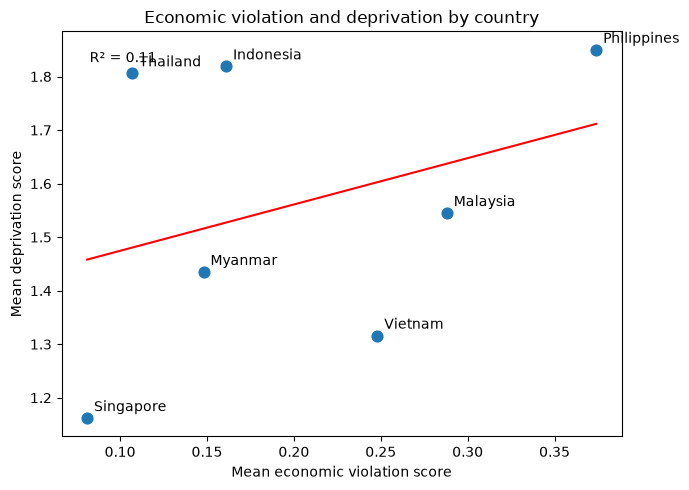

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# make sure both tables have a 'country' column and the right score names
EV1_df = EV1_df.rename(columns={EV1_df.columns[0]: 'country', EV1_df.columns[1]: 'EV_mean'})
deprivation_df = deprivation_df.rename(columns={deprivation_df.columns[0]: 'country'})

reg_df3 = EV1_df.merge(deprivation_df, on='country')
print(reg_df3.shape)   # should be (7, 3)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(reg_df3['EV_mean'], reg_df3['deprivation_mean'], s=60)

# label each point with its country
for _, r in reg_df3.iterrows():
    ax.annotate(r['country'], (r['EV_mean'], r['deprivation_mean']),
                xytext=(5, 5), textcoords='offset points')

# best fit line
slope, intercept = np.polyfit(reg_df3['EV_mean'], reg_df3['deprivation_mean'], 1)
x = np.linspace(reg_df3['EV_mean'].min(), reg_df3['EV_mean'].max(), 100)
ax.plot(x, intercept + slope * x, color='red')

# R² on the plot
r2 = np.corrcoef(reg_df3['EV_mean'], reg_df3['deprivation_mean'])[0, 1] ** 2
ax.text(0.05, 0.95, f"R² = {r2:.2f}", transform=ax.transAxes, va='top')

ax.set_xlabel('Mean economic violation score')
ax.set_ylabel('Mean deprivation score')
ax.set_title('Economic violation and deprivation by country')
plt.tight_layout()
plt.show()

OLS Regression and scatter plot (Personal Norm Violation and deprevation score)

In [30]:
import statsmodels.formula.api as smf

deprivation_df = deprivation_df.rename(columns={deprivation_df.columns[0]: 'country'})
PV1_df = PV1_df.rename(columns={PV1_df.columns[0]: 'country',
                                PV1_df.columns[1]: 'PV_mean'})

reg_df2 = deprivation_df.merge(PV1_df, on='country')
print(reg_df2.shape)   # should be (7, 3)

model2 = smf.ols('PV_mean ~ deprivation_mean', data=reg_df2).fit()
print(model2.summary())


(7, 3)
                            OLS Regression Results                            
Dep. Variable:                PV_mean   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                 -0.170
Method:                 Least Squares   F-statistic:                    0.1262
Date:                Tue, 06 Oct 2026   Prob (F-statistic):              0.737
Time:                        11:07:35   Log-Likelihood:                -8.4994
No. Observations:                   7   AIC:                             21.00
Df Residuals:                       5   BIC:                             20.89
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            3.8917      

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:3158: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  omni, omnipv = cached("omni_normtest", lambda: omni_normtest(self.wresid))


(7, 3)


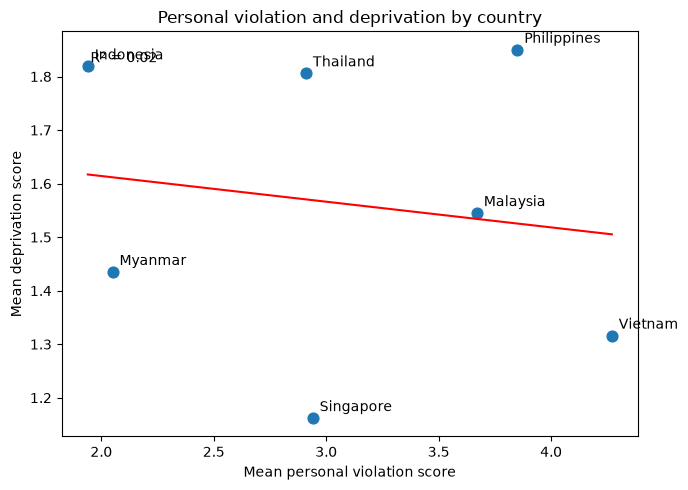

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# make sure both tables have a 'country' column and the right score names
PV1_df = PV1_df.rename(columns={PV1_df.columns[0]: 'country', PV1_df.columns[1]: 'PV_mean'})
deprivation_df = deprivation_df.rename(columns={deprivation_df.columns[0]: 'country'})

reg_df4 = PV1_df.merge(deprivation_df, on='country')
print(reg_df4.shape)   # should be (7, 3)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(reg_df4['PV_mean'], reg_df4['deprivation_mean'], s=60)

# label each point with its country
for _, r in reg_df4.iterrows():
    ax.annotate(r['country'], (r['PV_mean'], r['deprivation_mean']),
                xytext=(5, 5), textcoords='offset points')

# best fit line
slope, intercept = np.polyfit(reg_df4['PV_mean'], reg_df4['deprivation_mean'], 1)
x = np.linspace(reg_df4['PV_mean'].min(), reg_df4['PV_mean'].max(), 100)
ax.plot(x, intercept + slope * x, color='red')

# R² on the plot
r2 = np.corrcoef(reg_df4['PV_mean'], reg_df4['deprivation_mean'])[0, 1] ** 2
ax.text(0.05, 0.95, f"R² = {r2:.2f}", transform=ax.transAxes, va='top')

ax.set_xlabel('Mean personal violation score')
ax.set_ylabel('Mean deprivation score')
ax.set_title('Personal violation and deprivation by country')
plt.tight_layout()
plt.show()

In [33]:
import pandas as pd
import numpy as np

# Start from 'sea' (already has hardship recoded, SEA only)
df_individual = sea.copy()

# Add ethics items (Q177-Q181) from df_raw
ethics_cols = ['Q177', 'Q178', 'Q179', 'Q180', 'Q181']
for col in ethics_cols:
    raw_col = pd.to_numeric(df_raw.loc[df_individual.index, col], errors='coerce')
    df_individual[col] = raw_col.where(raw_col > 0)

# Create individual indices
hardship_items = ['Q51', 'Q53', 'Q54', 'Q55']
df_individual['deprivation_mean'] = df_individual[hardship_items].mean(axis=1, skipna=True)

# EV mean (rescaled 0-1)
EV_raw = df_individual[ethics_cols].mean(axis=1, skipna=True)
df_individual['EV_mean'] = (EV_raw - 1) / 9

# Drop missing values
df_model = df_individual.dropna(subset=['deprivation_mean', 'EV_mean', 'W_WEIGHT'])

print(f"✅ df_model created!")
print(f"   N = {len(df_model)} individuals")
print(f"   Countries: {df_model['B_COUNTRY_ALPHA'].unique()}")

✅ df_model created!
   N = 11601 individuals
   Countries: <StringArray>
['IDN', 'MMR', 'MYS', 'PHL', 'SGP', 'THA', 'VNM']
Length: 7, dtype: str


In [36]:

# THIS IS FOR HARDSHIP AND ECONOMIC NORMS 
import statsmodels.formula.api as smf

results_by_country = {}

for country in df_model['B_COUNTRY_ALPHA'].unique():
    df_country = df_model[df_model['B_COUNTRY_ALPHA'] == country].copy()

    if len(df_country) < 100:
        print(f"\n{country}: N={len(df_country)} (too small, skipping)")
        continue

    model = smf.ols(
        "EV_mean ~ deprivation_mean",
        data=df_country
    ).fit(weights=df_country['W_WEIGHT'])

    results_by_country[country] = model

    print(f"\n{'='*70}")
    print(f"{country} (N={len(df_country)})")
    print('='*70)
    print(model.summary())


IDN (N=3199)
                            OLS Regression Results                            
Dep. Variable:                EV_mean   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     113.7
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           4.09e-26
Time:                        11:12:28   Log-Likelihood:                 1068.1
No. Observations:                3199   AIC:                            -2132.
Df Residuals:                    3197   BIC:                            -2120.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.065

In [40]:
print(df_model.columns.tolist())

['B_COUNTRY_ALPHA', 'W_WEIGHT', 'Q51', 'Q53', 'Q54', 'Q55', 'Q177', 'Q178', 'Q179', 'Q180', 'Q181', 'deprivation_mean', 'EV_mean']


In [41]:
q_cols_personal = [f"Q{i}" for i in range(182, 196)]

# bring in the Q182-195 columns from df_raw, matched by respondent
df_model = df_model.join(df_raw.loc[df_model.index, q_cols_personal])

# clean: numeric + drop missing codes
df_model[q_cols_personal] = df_model[q_cols_personal].apply(pd.to_numeric, errors='coerce')
df_model[q_cols_personal] = df_model[q_cols_personal].where(df_model[q_cols_personal] > 0)

# average across the 14 items per respondent
df_model['PV_mean'] = df_model[q_cols_personal].mean(axis=1)

print(df_model[['PV_mean']].describe())

            PV_mean
count  11599.000000
mean       2.881552
std        1.716058
min        1.000000
25%        1.571429
50%        2.357143
75%        3.857143
max       10.000000


In [42]:
print(df_model.columns.tolist())
print(df_model[['PV_mean']].describe())

['B_COUNTRY_ALPHA', 'W_WEIGHT', 'Q51', 'Q53', 'Q54', 'Q55', 'Q177', 'Q178', 'Q179', 'Q180', 'Q181', 'deprivation_mean', 'EV_mean', 'Q182', 'Q183', 'Q184', 'Q185', 'Q186', 'Q187', 'Q188', 'Q189', 'Q190', 'Q191', 'Q192', 'Q193', 'Q194', 'Q195', 'PV_mean']
            PV_mean
count  11599.000000
mean       2.881552
std        1.716058
min        1.000000
25%        1.571429
50%        2.357143
75%        3.857143
max       10.000000


In [46]:
results_by_country_personal = {}

print("="*70)
print("INDIVIDUAL-LEVEL OLS: Deprivation -> Personal Norm Violations")
print("="*70)

for country in df_model['B_COUNTRY_ALPHA'].unique():
    df_country = df_model[df_model['B_COUNTRY_ALPHA'] == country].copy()
    if len(df_country) < 100:
        print(f"\n⚠️  {country}: N={len(df_country)} (too small, skipping)")
        continue
    model = smf.ols("PV_mean ~ deprivation_mean", data=df_country).fit(weights=df_country['W_WEIGHT'])
    results_by_country_personal[country] = model
    print(f"\n{country} (N={len(df_country)})")
    print(model.summary())

with open('../output/tables/country_regressions_personal.txt', 'w') as f:
    for country, model in results_by_country_personal.items():
        f.write(f"{'='*70}\n{country}\n{'='*70}\n")
        f.write(str(model.summary()))
        f.write('\n\n')

print("\nSaved: country_regressions_personal.txt")

INDIVIDUAL-LEVEL OLS: Deprivation -> Personal Norm Violations

IDN (N=3199)
                            OLS Regression Results                            
Dep. Variable:                PV_mean   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     31.63
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           2.02e-08
Time:                        11:33:48   Log-Likelihood:                -5060.3
No. Observations:                3198   AIC:                         1.012e+04
Df Residuals:                    3196   BIC:                         1.014e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

In [47]:
# Comparison of OLS 
comparison_clean = pd.DataFrame({
    country: {
        'Economic Norms: β (coefficient)': results_by_country[country].params['deprivation_mean'],
        'Economic Norms: p-value': results_by_country[country].pvalues['deprivation_mean'],
        'Economic Norms: Significant?': 'Yes' if results_by_country[country].pvalues['deprivation_mean'] < 0.05 else 'No',
        'Personal Norms: β (coefficient)': results_by_country_personal[country].params['deprivation_mean'],
        'Personal Norms: p-value': results_by_country_personal[country].pvalues['deprivation_mean'],
        'Personal Norms: Significant?': 'Yes' if results_by_country_personal[country].pvalues['deprivation_mean'] < 0.05 else 'No',
    }
    for country in results_by_country
}).T

comparison_clean[['Economic Norms: β (coefficient)', 'Economic Norms: p-value',
                   'Personal Norms: β (coefficient)', 'Personal Norms: p-value']] = \
    comparison_clean[['Economic Norms: β (coefficient)', 'Economic Norms: p-value',
                       'Personal Norms: β (coefficient)', 'Personal Norms: p-value']].astype(float).round(4)

print(comparison_clean)
comparison_clean.to_csv('../output/tables/individual_level_comparison.csv')

     Economic Norms: β (coefficient)  Economic Norms: p-value  \
IDN                           0.0493                   0.0000   
MMR                           0.0331                   0.0000   
MYS                           0.0702                   0.0000   
PHL                           0.0238                   0.0233   
SGP                           0.0732                   0.0000   
THA                           0.0436                   0.0000   
VNM                           0.0078                   0.5266   

    Economic Norms: Significant?  Personal Norms: β (coefficient)  \
IDN                          Yes                           0.1768   
MMR                          Yes                           0.1027   
MYS                          Yes                           0.5347   
PHL                          Yes                           0.1074   
SGP                          Yes                           0.1059   
THA                          Yes                           0.0111